<a href="https://colab.research.google.com/github/dennymarcels/AreTheseTwoPeopleRelated/blob/master/unk_treatment/Identifica%C3%A7%C3%A3o_de_POS_tags_relevantes_%C3%A0_tarefa_de_tradu%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este documento tem por objetivo fazer a anotação morfológica do corpus disponível em português, para identificar quais categorias morfológicas são mais frequentes, e assim definir quais categorias vamos utilizar para a classificação de UNKs.

# Baixando e instalando dependências

In [28]:
!pip install spacy --upgrade

     |████████████████████████████████| 5.9 MB 7.2 MB/s 
     |████████████████████████████████| 623 kB 48.9 MB/s 
     |████████████████████████████████| 10.1 MB 50.5 MB/s 
     |████████████████████████████████| 456 kB 38.4 MB/s 
     |████████████████████████████████| 42 kB 1.7 MB/s 
  Attempting uninstall: catalogue
    Found existing installation: catalogue 1.0.0
    Uninstalling catalogue-1.0.0:
      Successfully uninstalled catalogue-1.0.0
  Attempting uninstall: srsly
    Found existing installation: srsly 1.0.5
    Uninstalling srsly-1.0.5:
      Successfully uninstalled srsly-1.0.5
  Attempting uninstall: thinc
    Found existing installation: thinc 7.4.0
    Uninstalling thinc-7.4.0:
      Successfully uninstalled thinc-7.4.0
  Attempting uninstall: spacy
    Found existing installation: spacy 2.2.4
    Uninstalling spacy-2.2.4:
      Successfully uninstalled spacy-2.2.4


Vou usar o modelo large do spacy PT, pela maior precisão.

In [30]:
!python -m spacy download pt_core_news_lg

     |████████████████████████████████| 576.7 MB 21 kB/s 
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')


In [49]:
!pip install --upgrade matplotlib

     |████████████████████████████████| 10.3 MB 8.4 MB/s 
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.2.2
    Uninstalling matplotlib-3.2.2:
      Successfully uninstalled matplotlib-3.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albumentations 0.1.12 requires imgaug<0.2.7,>=0.2.5, but you have imgaug 0.2.9 which is incompatible.


In [1]:
from google.colab import auth, output
import sys
auth.authenticate_user()
!gcloud source repos clone github_hand-talk_pytools --project='ht-community' && pip install /content/github_hand-talk_pytools
output.clear()

# Carregando dependências

In [1]:
from handtalk.community import Community
import cereja as cj
import joblib
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
import random
import matplotlib.pyplot as plt

🍒 Using Cereja v.1.5.8


# Baixando dados do Community

In [2]:
cmt = Community('HT-BZS')

Vou usar como corpus de análise uma junção do corpus legado e do último corpus disponível até hoje.

In [3]:
cmt.storage.download('HT-BZS/bzs/corpora/legacy/CORPUS_BZS.csv', '/content/', 'corpus_legado.csv')

In [4]:
cmt.storage.download('HT-BZS/bzs/corpora/2021-06-01/CORPUS_BZS.csv', '/content/', 'corpus_junho.csv')

In [5]:
corpus_legado = pd.read_csv('corpus_legado.csv', index_col = 0)
corpus_legado

,source_sentence,target_sentence
0,"Para acessar a Parte 01 , clique aqui.",¶3xP2r7NFnEk9yUJwnN0E 0 1 0
1,Leia aqui!,¶m4HFzgAfwhgZNdUTk3ce ¶eLVt9pWi6hNSX41eyNii
2,Sinto que estamos fazendo a mesma coisa,¶xBShmfmwEwVmELEn2C6Y ¶LoiFpmBchfgoSQTBuuON ¶U...
3,"R$ 1,10 milhão Venda",1 ¶lKSmldnpXZg61uC3GNaJ 10 ¶iajwMBZwUvTgbLFdlc...
4,um dia histórico,¶sHO93EGZkHflUb4HznZ5 ¶qaf30UmtmfO0LLXpkVXo
...,...,...
204807,Tem gosto de batata,¶IbpuqvBlFQYMC75mbeou ¶noa2kTe1L0LVcXf7mcbc
204808,Tem gosto de melancia,¶IbpuqvBlFQYMC75mbeou ¶r0AzyuEHNWeViicFEFBO
204809,Tem gosto de abóbora,¶IbpuqvBlFQYMC75mbeou ¶8h2vuQSL5gEXu3aFZ8v4
204810,Tem gosto de goiaba,¶IbpuqvBlFQYMC75mbeou ¶UkBYH629ayvC68FXCiDe


In [6]:
corpus_junho = pd.read_csv('corpus_junho.csv', index_col = 0).drop('video', axis = 1)
corpus_junho

,source_sentence,target_sentence
0,a b c d f g,a b c d f g
1,v o c e,v o c c
2,pó pó pó pó,pó pó pó pó
3,Previdência social,¶RZQTcB3rV5zWMlR2eM2j
4,Bolsa de Valores,¶qdf3nS5mTj2ZvUqvjE8P
...,...,...
7728,eu gosto da minha casa,¶J0mYECu18NXr5FhXmFR2 ¶1W1YTJLtVV4FFJ8lZYv3 ¶l...
7729,boa noite eu amo voce,¶1W1YTJLtVV4FFJ8lZYv3 noite ¶uoIVnpLtdtg367RSB...
7730,o que você fez de bom hoje,¶G8SC11YlrbGbxzzRJlBK ¶0wapz4A8pBqUQAsQbIoQ qu...
7731,sim eu quero aprender libras,sim ¶0RGqInzx9O3AbRRw0ubO ¶IsJU6vfScjlbgK9WWcw...


In [7]:
corpus = corpus_legado.append(corpus_junho).iloc[:, 0:1]
corpus

,source_sentence
0,"Para acessar a Parte 01 , clique aqui."
1,Leia aqui!
2,Sinto que estamos fazendo a mesma coisa
3,"R$ 1,10 milhão Venda"
4,um dia histórico
...,...
7728,eu gosto da minha casa
7729,boa noite eu amo voce
7730,o que você fez de bom hoje
7731,sim eu quero aprender libras


# Tratamento dos dados

Primeiro vou tirar a pontuação.

In [8]:
import re
corpus['source_sentence'] = corpus['source_sentence'].map(lambda x: re.sub(r'[^\w\s]', '', x))
corpus

,source_sentence
0,Para acessar a Parte 01 clique aqui
1,Leia aqui
2,Sinto que estamos fazendo a mesma coisa
3,R 110 milhão Venda
4,um dia histórico
...,...
7728,eu gosto da minha casa
7729,boa noite eu amo voce
7730,o que você fez de bom hoje
7731,sim eu quero aprender libras


Adicionar quantas palavras (identificadas por caracteres separados por espaço) cada frase tem.

In [9]:
corpus['len'] = corpus['source_sentence'].map(lambda x: len(x.split(' ')))
corpus

,source_sentence,len
0,Para acessar a Parte 01 clique aqui,8
1,Leia aqui,2
2,Sinto que estamos fazendo a mesma coisa,7
3,R 110 milhão Venda,4
4,um dia histórico,3
...,...,...
7728,eu gosto da minha casa,5
7729,boa noite eu amo voce,5
7730,o que você fez de bom hoje,7
7731,sim eu quero aprender libras,5


Também vou identificar quantas palavras são um único caractere (unichar), para identificar situações onde o texto não tenha significado semântico suficiente para classificação (como exemplo, "a b c d e f").

In [10]:
from collections import Counter
corpus['n_unichar'] = corpus['source_sentence'].map(lambda x: Counter(len(y) for y in x.split(' '))[1])
corpus

,source_sentence,len,n_unichar
0,Para acessar a Parte 01 clique aqui,8,1
1,Leia aqui,2,0
2,Sinto que estamos fazendo a mesma coisa,7,1
3,R 110 milhão Venda,4,1
4,um dia histórico,3,0
...,...,...,...
7728,eu gosto da minha casa,5,0
7729,boa noite eu amo voce,5,0
7730,o que você fez de bom hoje,7,1
7731,sim eu quero aprender libras,5,0


Agora vou identificar a razão de unichars em cada frase.

In [11]:
corpus['ratio'] = corpus['n_unichar']/corpus['len']
corpus

,source_sentence,len,n_unichar,ratio
0,Para acessar a Parte 01 clique aqui,8,1,0.125000
1,Leia aqui,2,0,0.000000
2,Sinto que estamos fazendo a mesma coisa,7,1,0.142857
3,R 110 milhão Venda,4,1,0.250000
4,um dia histórico,3,0,0.000000
...,...,...,...,...
7728,eu gosto da minha casa,5,0,0.000000
7729,boa noite eu amo voce,5,0,0.000000
7730,o que você fez de bom hoje,7,1,0.142857
7731,sim eu quero aprender libras,5,0,0.000000


Para que as frases tenham significado semântico suficiente para o algoritmo conseguir fazer alguma anotação, vou filtrar somente frases com pelo menos 3 palavras, cuja razão de unichars seja menor do que 2/3 (ou seja, em frases com apenas 3 palavras, só um unichar é aceito).

In [12]:
corpus = corpus.query('len >= 3 and ratio <= 0.66')
corpus

,source_sentence,len,n_unichar,ratio
0,Para acessar a Parte 01 clique aqui,8,1,0.125000
2,Sinto que estamos fazendo a mesma coisa,7,1,0.142857
3,R 110 milhão Venda,4,1,0.250000
4,um dia histórico,3,0,0.000000
5,Você realmente possa ser salva,5,0,0.000000
...,...,...,...,...
7728,eu gosto da minha casa,5,0,0.000000
7729,boa noite eu amo voce,5,0,0.000000
7730,o que você fez de bom hoje,7,1,0.142857
7731,sim eu quero aprender libras,5,0,0.000000


Inspeção final.

In [13]:
corpus.sort_values('len')

,source_sentence,len,n_unichar,ratio
56435,ocupamos todos lugares,3,0,0.000000
43402,vida de jesus,3,0,0.000000
155234,Corey vamos,3,0,0.000000
155233,Adorar a deus,3,1,0.333333
87387,crianças estão dormindo,3,0,0.000000
...,...,...,...,...
23874,As principais demandas são cirurgias restaur...,51,1,0.019608
173357,Luzia Cristina Ferreira de Ornelas eu te amo m...,53,1,0.018868
77299,Estes foram alguns dos projetos resultantes do...,55,1,0.018182
79220,Fabio Meireles diretor na produtora de filmes...,55,6,0.109091


In [14]:
corpus.sort_values('n_unichar')

,source_sentence,len,n_unichar,ratio
90712,Que Deus te abençoe sempre,5,0,0.000000
108506,Então estou feliz,3,0,0.000000
108504,Centro apoio ao surdo,4,0,0.000000
108502,Minha alegria foi imensa,4,0,0.000000
108499,só queria conhecer ela,4,0,0.000000
...,...,...,...,...
8337,O que existe são práticas que podemos utilizar...,38,8,0.210526
84778,A área de Compliance em conjunto com Auditori...,57,9,0.157895
104092,1 com 2 cidade 3 junto 4 interior 5 Bahia 6 Sa...,28,9,0.321429
108732,O curso de Administração do UniBH incentiva a ...,35,9,0.257143


# Anotação com spacy

In [15]:
import spacy
nlp = spacy.load('pt_core_news_lg')

In [16]:
docs = [nlp(sentence) for sentence in corpus['source_sentence']]

É relevante observar que a anotação é relativamente lenta. Num ambiente sem GPU, a anotação do dataset inteiro levou cerca de 15 minutos.

Recuperando todas as anotações em uma única lista.

In [17]:
pos = [token.pos_ for doc in docs for token in doc]

Contando.

In [ ]:
counts = Counter(pos)

Em ordem decrescente:

In [19]:
counts.most_common()

[('NOUN', 152814),
 ('VERB', 123404),
 ('PRON', 79338),
 ('DET', 70955),
 ('ADP', 63537),
 ('PROPN', 56151),
 ('ADV', 54818),
 ('AUX', 42896),
 ('ADJ', 41776),
 ('SPACE', 20830),
 ('CCONJ', 18397),
 ('SCONJ', 18237),
 ('NUM', 13316),
 ('INTJ', 1494),
 ('PUNCT', 531),
 ('X', 525),
 ('SYM', 230)]

Em frequência decrescente:

In [20]:
sum_particles = sum(counts.values())
for particle in counts:
    counts[particle] = counts[particle]/sum_particles

In [21]:
counts.most_common()

[('NOUN', 0.20126993911088456),
 ('VERB', 0.16253429375606684),
 ('PRON', 0.10449536318124884),
 ('DET', 0.09345418960051313),
 ('ADP', 0.08368400880343603),
 ('PROPN', 0.07395597491731962),
 ('ADV', 0.07220029265761298),
 ('AUX', 0.056497934142817445),
 ('ADJ', 0.05502279225919297),
 ('SPACE', 0.027435004853480216),
 ('CCONJ', 0.024230522529499546),
 ('SCONJ', 0.024019787974696047),
 ('NUM', 0.017538383323521006),
 ('INTJ', 0.0019677339054776496),
 ('PUNCT', 0.0006993753037541044),
 ('X', 0.0006914727579489733),
 ('SYM', 0.00030293092253002636)]

Visualizando em gráfico a proporção do corpus que é coberta a cada adição de uma nova categoria morfológica. No início vão estar as categorias que mais contribuem, ou seja, as de maior frequência no corpus. As barras indicam a proporção acumulada até aquela categoria.

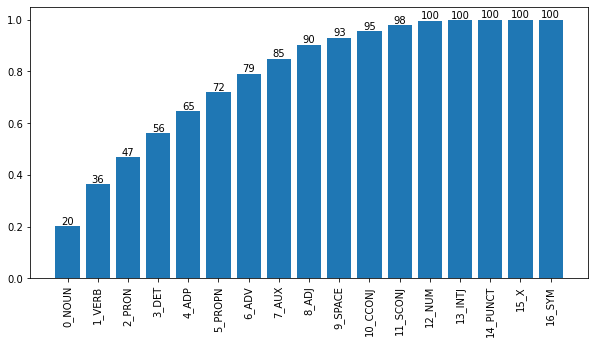

In [29]:
particles = [str(i) + '_' + x[0] for i, x in enumerate(counts.most_common())]
proportions = [x[1] for x in counts.most_common()]
proportions_cum = np.cumsum(proportions)

plt.figure(figsize = (10, 5))
fig = plt.bar(particles, proportions_cum)
plt.bar_label(fig, [round(100*x) for x in proportions_cum])
plt.xticks(rotation = 90);

Aqui nós vemos que a utilização de 4 categorias (NOUN, VERB, PRON e DET) cobre 56% do corpus, sobrando 44% para as demais categorias.

Significado das categorias:

In [46]:
for particle, _ in counts.most_common():
    print(particle, ':', spacy.explain(particle))

NOUN : noun
VERB : verb
PRON : pronoun
DET : determiner
ADP : adposition
PROPN : proper noun
ADV : adverb
AUX : auxiliary
ADJ : adjective
SPACE : space
CCONJ : coordinating conjunction
SCONJ : subordinating conjunction
NUM : numeral
INTJ : interjection
PUNCT : punctuation
X : other
SYM : symbol
